In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os

ação = "PETR4.SA"
arquivo = "petr4_historico.csv"

if os.path.exists(arquivo):
    df = pd.read_csv(arquivo, header=[0, 1], index_col=0, parse_dates=True)
else:
    df = yf.download(ação, start="2016-01-01", end="2026-09-16")
    df.to_csv(arquivo)

Vamos também puxar os dados do CDI no período, pois, enquanto o valor não estiver investido na ação PETR4, o capital não fica parado: ele estaria aplicado em um investimento livre de risco que rende próximo ao CDI. Usar o CDI torna o resultado final mais real, já que ele será usado como rendimento seguro do capital nos dias fora do mercado e também como taxa livre de risco no cálculo do Sharpe ratio, que mede o retorno obtido acima do que se teria sem correr risco nenhum, em relação ao risco tomado.

In [3]:
import requests

def baixar_cdi(inicio, fim):
    # série 12 do Banco Central é referente ao CDI diário, em % ao dia. Baixamos ano a ano porque a API limita o tamanho de cada consulta
    partes = []
    for ano in range(inicio.year, fim.year + 1):
        ini = max(inicio, pd.Timestamp(f"{ano}-01-01")).strftime("%d/%m/%Y")
        fi = min(fim, pd.Timestamp(f"{ano}-12-31")).strftime("%d/%m/%Y")
        url = ("https://api.bcb.gov.br/dados/serie/bcdata.sgs.12/dados"
               f"?formato=json&dataInicial={ini}&dataFinal={fi}")
        partes.append(pd.DataFrame(requests.get(url, timeout=30).json()))
    cdi = pd.concat(partes)
    cdi["data"] = pd.to_datetime(cdi["data"], dayfirst=True)
    cdi["valor"] = cdi["valor"].astype(float) / 100  # transformando de porcentagem para decimal
    return cdi.set_index("data")["valor"]

arquivo_cdi = "cdi_historico.csv"
if os.path.exists(arquivo_cdi):
    cdi = pd.read_csv(arquivo_cdi, index_col=0, parse_dates=True).squeeze()
else:
    cdi = baixar_cdi(df.index[0], df.index[-1])
    cdi.to_csv(arquivo_cdi)

# o CDI publicado na data d remunera o dinheiro de d até o próximo dia útil,
# então o caixa mantido entre o fechamento de t-1 e o de t rende o CDI de t-1: por isso o shift(1)
df["cdi"] = cdi.reindex(df.index).ffill().shift(1)
print("dias sem CDI:", df["cdi"].isna().sum())  # deve dar 1 (o primeiro dia, por causa do shift)
print(df["cdi"].describe())

dias sem CDI: 1
count    2666.000000
mean        0.000368
std         0.000154
min         0.000075
25%         0.000246
50%         0.000402
75%         0.000508
max         0.000551
Name: cdi, dtype: float64


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 2667 entries, 2016-01-04 to 2026-09-15
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, PETR4.SA)   2667 non-null   float64
 1   (High, PETR4.SA)    2667 non-null   float64
 2   (Low, PETR4.SA)     2667 non-null   float64
 3   (Open, PETR4.SA)    2667 non-null   float64
 4   (Volume, PETR4.SA)  2667 non-null   int64  
 5   (cdi, )             2666 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 145.9 KB


Price,Close,High,Low,Open,Volume,cdi
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,
count,2667.000000,2667.000000,2667.000000,2667.000000,2.667000e+03,2666.000000
mean,13.949341,14.122416,13.773964,13.947020,5.720858e+07,0.000368
std,11.608899,11.717583,11.488250,11.595870,3.318086e+07,0.000154
min,1.052146,1.069682,1.032106,1.052146,0.000000e+00,0.000075
25%,5.076731,5.187019,4.998856,5.086691,3.557460e+07,0.000246
50%,7.879003,8.002468,7.759967,7.876268,5.025670e+07,0.000402
75%,25.479664,25.744457,25.131351,25.410296,6.954880e+07,0.000508
max,50.430000,50.700001,49.029999,49.509998,4.902304e+08,0.000551


O Data Frame importado se refere a ação da Petrobras (PETR4) no periodo de 01/01/2016 até 16/09/2026.
As colunas do Data Frame são Close (valor da ação no fechamento da bolsa), High (pico do valor da ação no dia), Low (menor valor da ação no dia), Open (valor da ação no momento de abertura da bolsa) e Volume (total de ações que foram movimentadas no dia)
No Data Frame, não há nenhum informação faltante, então, podemos seguir direto para a visualização e manipulação desses dados.
Nesse notebook usaremos apenas o valor de fechamento da bolsa (Close), pois queremos um resultado a longo prazo do valor da ação, não nos interessando os valores de volatilidade diária como High e Low.

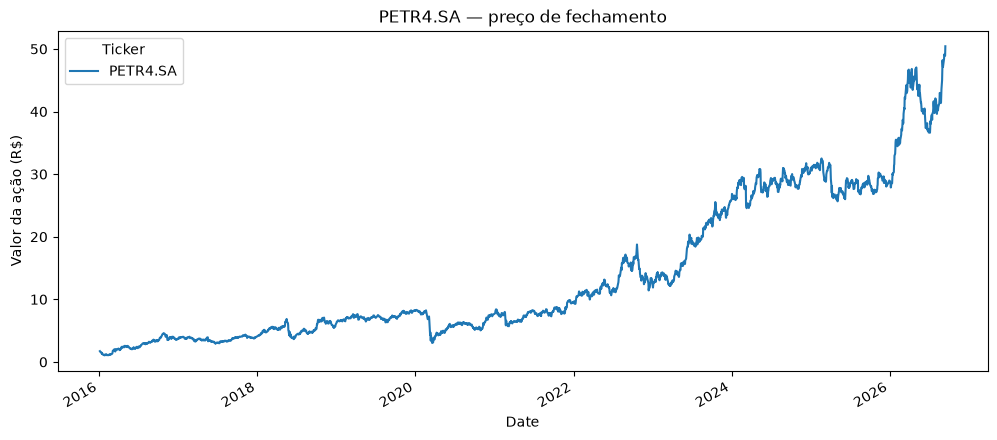

In [5]:
'''aqui plotamos uma gráfico do valor da ação no período estudado para facilitar a visualização do comportamento da ação ao longo do tempo'''
df["Close"].plot(figsize=(12,5), title=f"{ação} — preço de fechamento")
plt.ylabel("Valor da ação (R$)")
plt.show()

O gráfico acima foi inspecionado de forma visual, percebe-se que não foi visto nenhuma incoerência como saltos aburptos ou um padrão que fosse visivelmente estranho. Como já checado, não existe nenhum dado faltante, o que possibilita o prosseguimento do código sem nenhum problema.

Por esse motivo, o histórico foi salvo em petr4_historico.csv. A primeira célula do notebook lê esse arquivo quando ele existe e só consulta o yfinance se ele não existir. Assim, qualquer pessoa que rodar o código parte exatamente dos mesmos dados e chega aos mesmos resultados.

Nesta primeira parte, usamos a combinação de 10/50 como exemplo para construir e visualizar a estratégia passo a passo. A escolha da combinação de fato é feita mais adiante pelo walk-forward, que testa nove combinações e seleciona a melhor em cada janela de treino.

In [6]:
df["MA_curta"] = df["Close"].rolling(window=10).mean() # aqui criamos a média aritmética curta usando os dados de fechamento (close) na janela (window) dos últimos 10 dias, o por isso do 'rolling'
df["MA_longa"] = df["Close"].rolling(window=50).mean() # aqui é feito coisa semelhante a média aritmética curta, porém usando os dados dos ultimos 50 dias. vale destacar que do dia 1 ao 49, não existem 50 dias anteriores para ser feito a média do valor de fechamento, sendo assim definida como 'NaN', mesma lógica se aplica a média curta

Vamos plotar em um gráfico só o comportamento da ação, da média curta e da média longa nos últimos dois anos para podermos ter uma noção mais real e precisa do comportamento das médias em relacao ao comportamento real da ação.

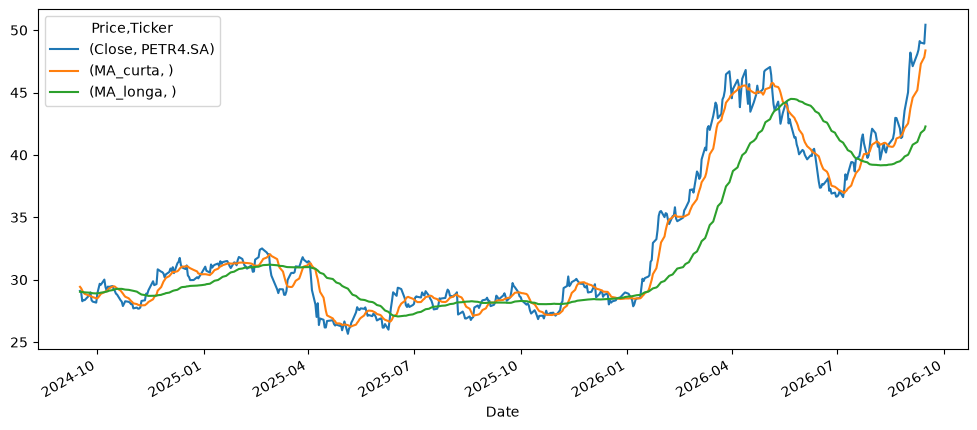

In [7]:
df.loc["2024-09-16":"2026-09-16", ["Close", "MA_curta", "MA_longa"]].plot(figsize=(12,5))
plt.show()

Olhando para o gráfico acima, percebe-se que o modelo MA crossover é ideal para momentos em que há um tendência clara de crescimento ou queda do preço da ação como é percebido no periodo de 01/26 ate 05/26. porém, não sendo interessante para momentos de oscilações sem direção definida, como visto em 09/25 até 01/26, nesse momento acontece a oscilacão sem uma tendência a ser seguida, gerando cruzamento de sinais que acarretam no efeito whipsaw, mostrando a fragilidade do modelo nessa situação.

Outro tópico para se ter atenção é o tamanho da janela usada no cálculo das médias. Janelas longas deixam as médias pouco sensíveis às variações diárias, o que gera atraso (lag): o sinal de compra ou venda chega tarde e perde o timing da virada de tendência. Já janelas curtas deixam as médias quase como um espelho do preço, sensíveis a qualquer variação, o que gera ruído: os sinais mudam com muita frequência e aumentam o whipsaw e o custo de transação. Escolher a janela é, portanto, um trade-off entre atraso e ruído, e é por isso que mais adiante testamos várias combinações no walk-forward em vez de fixar uma só.

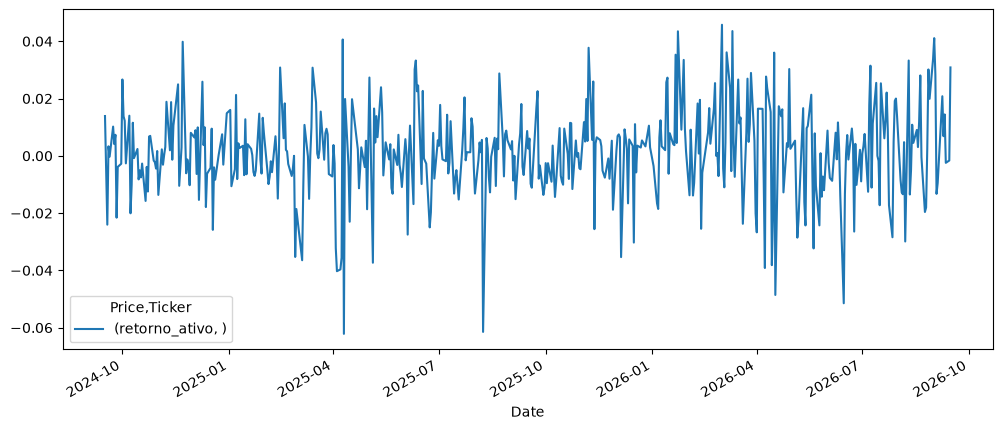

In [8]:
df["retorno_ativo"] = df["Close"].pct_change() # feito pra calcular a diferença percentual do valor da ação entre dias consecutivos
df.loc["2024-09-16":"2026-09-16", ["retorno_ativo"]].plot(figsize=(12,5))
plt.show()

Observando o gráfico de retorno diário acima, a variação percentual da ação fica normalmente entre aproximadamente -2% e +3% na maioria dos dias, sendo uma volatilidade diária normal para a ação em destaque. Apesar disso, existem poucos dias com quedas um pouco maiores que o normal, cerca de -5% a -6%, sendo eventos reais do mercado. Além disso, o gráfico também não tem nenhuma tendência visual muito forte, uma vez que essa tendência vem da soma de muitos dias levemente positivos.

In [9]:
# aqui vamos criar a coluna 'sinal' que se refere se no momento a gente vai ter comprado ou não a ação, sendo 0 -> não comprada e 1 -> comprada
df["sinal"] = 0 # de início, coloca-se todas as linhas como 0, pois elas não estarão compradas inicialmente
df.loc[df["MA_curta"] > df["MA_longa"], "sinal"] = 1 # é feito a condição e do sinal, caso afirmativo, a ação é comprada
df["sinal"] = df["sinal"].shift(1) # essa linha é feita para tomar cuidado com o fato de que a média é calculada com base no valor da ação na hora do fechamento no dia D, então, se for visto que a condição para comprar ou vender a ação é satisfeita, essa compra ou venda só poderá ser feita no dia seguinte (D + 1), assim evitando o look-ahead bias.

In [10]:
'''Aqui aplicamos a estratégia de fato: multiplicamos o sinal (0 ou 1) pelo retorno do ativo daquele dia. Se a média curta for maior que a média longa (sinal de que a ação deve ser comprada ou mantê-la comprada) a estratégia pega o retorno cheio daquele dia. Em caso de média longa maior que média curta, a ação não deve estar comprada e, portanto, o capital fica aplicado rendendo o CDI do dia. Ou seja, nos momentos em que o capital não estiver aplicado na ação, ele estará aplicando no CDI, rendendo em uma taxa livre de riscos'''
df["estrategia_de_retorno"] = df["sinal"] * df["retorno_ativo"] + (1 - df["sinal"]) * df["cdi"]

In [11]:
custo_por_operacao = 0.001  # vamos usar 0,1% como custo de operação definido para venda e compra de acoes
trocas = df["sinal"].diff().abs() # compara-se o valor que "sinal" se refere é o mesmo da linha anterior
df["estrategia_de_retorno"] -= trocas * custo_por_operacao # quando é feito alguma operacao, é descontado um certo valor, como é feito nas corretoras

In [12]:
df["equity_estrategia"] = (1 + df["estrategia_de_retorno"]).cumprod() # retorno efetivo do usuário, com o capital rendendo com a ação quando está dentro do mercado e com o CDI quando está fora do mercado
df["equity_benchmark"] = (1 + df["retorno_ativo"]).cumprod() # a nossa referência de valor desde o momento inicial de captação de dados

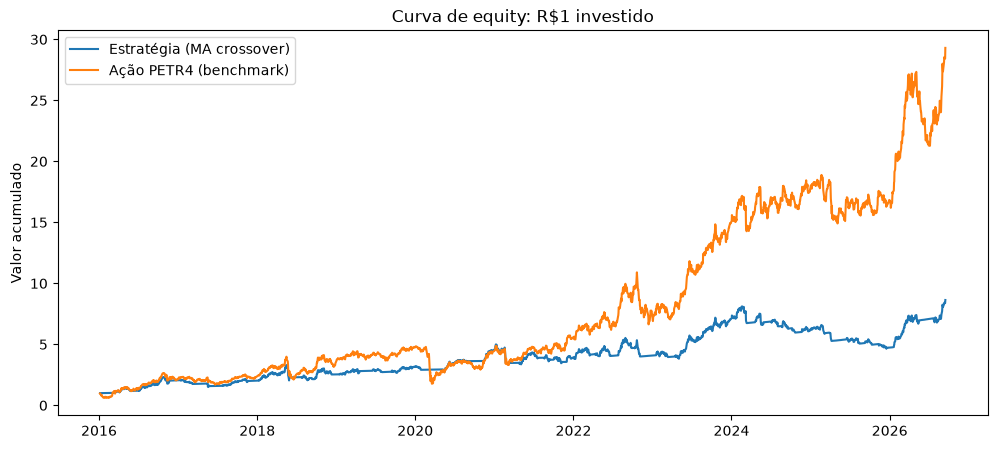

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df["equity_estrategia"], label="Estratégia (MA crossover)")
plt.plot(df["equity_benchmark"], label="Ação PETR4 (benchmark)")
plt.legend()
plt.title("Curva de equity: R$1 investido")
plt.ylabel("Valor acumulado")
plt.show()

Observando a curva de equity acima, percebe-se que a estratégia de MA crossover (azul), com a combinação 10/50 fixa usada como exemplo, rendeu significativamente menos que o buy-and-hold da PETR4 (laranja) ao longo do período inteiro: cada 1 real investido virou aproximadamente 8,50 reais na estratégia contra cerca de 29 reais no buy-and-hold. Isso provavelmente acontece porque o período analisado teve uma tendência de alta muito forte e sustentada, e qualquer estratégia que fica fora do mercado parte do tempo (como o MA crossover, que só entra depois que a média cruza) acaba perdendo uma fatia da subida em troca de proteção nos momentos de queda. Mesmo com o capital rendendo CDI nos dias fora do mercado, esse rendimento fica muito abaixo da alta da ação no período. Some-se a isso o custo de transação, pago toda vez que o sinal muda de posição, o que também corrói o retorno ao longo de tantos anos de dados.

Outro tópico a ser comentado é que esse resultado é in-sample: ele usa uma única combinação escolhida de antemão e foi calculado numa única passada sobre todo o histórico. Por isso, ainda não sabemos se esse padrão de subperformance se mantém ao longo do tempo ou se é específico desse período e dessa combinação. Essa parte analisaremos agora com o walk-forward validation, que separa os dados em janelas de treino (in-sample) e de teste (out-of-sample) para verificar se o que foi feito acima se sustenta em dados que a estratégia ainda não viu.

Abaixo, vamos criar uma função (gerar_estrategia_de_retorno) reaproveitando boa parte do que já fizemos, para que seja possível testar várias combinações de médias.

A função abaixo junta toda a lógica de sinal e estratégia, fazendo o cálculo das médias, geração do sinal, aplicação do retorno (da ação quando comprado e do CDI quando fora do mercado) e desconto do custo de transação em um único bloco parametrizado pela janela curta e longa. Assim, é possível testar as nove combinações de janelas (médias curtas de 5, 10 e 20 dias com médias longas de 50, 100 e 200 dias) chamando a mesma função com parâmetros diferentes, em vez de fazer o código para cada combinação.

Na mesma célula também definimos a função do Sharpe ratio, calculado sobre o retorno acima do CDI, pois ela passa a ser usada no walk-forward para escolher a melhor combinação em cada janela de treino.

In [14]:
def gerar_estrategia_de_retorno(precos, cdi, janela_curta, janela_longa, custo=0.001):
    ma_curta = precos.rolling(janela_curta).mean()
    ma_longa = precos.rolling(janela_longa).mean()
    sinal = (ma_curta > ma_longa).astype(int).shift(1)
    retorno_ativo = precos.pct_change()
    estrategia_de_retorno = sinal * retorno_ativo + (1 - sinal) * cdi # quando comprado é o retorno da acao, quando está fora do mercado é o CDI do dia
    trocas = sinal.diff().abs()
    estrategia_de_retorno -= trocas * custo
    return estrategia_de_retorno

'''calculamos o sharpe ratio para sabermos a relacao entre o retorno-risco no periodo, usando o retorno acima do CDI (excesso), ja que o CDI é o que se ganharia sem correr risco nenhum'''
def sharpe_ratio(retornos, livre_de_risco, dias_no_ano = 252):
    excesso = retornos - livre_de_risco.loc[retornos.index]
    return (excesso.mean() / excesso.std()) * (dias_no_ano ** 0.5) # poderia colocar o numero direto no 'return', mas nao faremos para evitar numeros mágicos no código.

Aqui calculamos o retorno de cada combinação em toda a série antes de entrar no loop de walk-forward. Fazemos isso por dois motivos: calcular cada média móvel de maneira separada em cada janela do walk-forward faria os primeiros dias de cada janela virarem NaN, perdendo dias que já têm dado disponível na série completa. Outro motivo, para não precisar recalcular a média móvel a cada iteração gerando baixa eficiência do código, o programa calcula a média móvel só uma vez e apenas recorta um resultado já existente.

In [15]:
'''aqui vamos usar esses nove pares de medias curtas e longas para comparar eles e ver qual par é mais efetivo para o que queremos'''
curtas = [5, 10, 20]
longas = [50, 100, 200]

combinacoes = {
    f"{c}/{l}": gerar_estrategia_de_retorno(df["Close"].squeeze(), df["cdi"], c, l, custo = custo_por_operacao)
    for c in curtas for l in longas
}
# é feito todas as combinações possíveis para médias curtas e médias longas
# o .squeeze() reduz a dimensao do data frame, possibilitando o prosseguimento do codigo

O loop abaixo implementa o walk-forward validation, que é basicamente: a cada iteração, usamos uma janela de treino (in-sample) de 600 dias para escolher, entre as nove combinações disponíveis, qual teve o maior Sharpe ratio nesse período. Depois disso, essa escolha é testada no período de 200 dias (out-of-sample) a seguir daquela janela de treino. Assim, é garantido que não haja look-ahead bias.

Antes do primeiro treino, pulamos os primeiros 200 dias da série (o aquecimento), pois é o tempo necessário para a maior média móvel testada, de 200 dias, existir. Sem isso, as combinações com médias longas passariam o início do treino fora do mercado por falta de dados, e não por decisão da estratégia, o que tornaria a comparação entre elas injusta.

Depois de cada iteração, a janela avança pelo tamanho da janela de teste (200 dias), e não pela soma treino + teste. Isso garante que os períodos de teste fiquem contínuos e sem sobreposição, então quando concatenamos todos os 'retorno_teste' no final, temos uma série out-of-sample contínua. Ficam de fora os primeiros 800 dias (200 de aquecimento e 600 do treino inicial) e os últimos dias que não completam uma janela de treino + teste inteira. No total, 867 dos 2667 dias do dataset não aparecem no 'retorno_walkforward'.

In [16]:
janela_treino = 600
janela_teste = 200
aquecimento = max(longas)  # dias necessários para a maior média móvel existir

resultados_out_of_sample = []
escolhas = []

inicio = aquecimento
while inicio + janela_treino + janela_teste <= len(df):
    fim_treino = inicio + janela_treino
    fim_teste = fim_treino + janela_teste

    melhor_combo, melhor_sharpe_treino = None, -float("inf")
    for nome, retorno in combinacoes.items():
        sharpe_treino = sharpe_ratio(retorno.iloc[inicio:fim_treino], df["cdi"])
        if sharpe_treino > melhor_sharpe_treino:
            melhor_sharpe_treino = sharpe_treino
            melhor_combo = nome

    retorno_teste = combinacoes[melhor_combo].iloc[fim_treino:fim_teste]
    resultados_out_of_sample.append(retorno_teste)
    escolhas.append(melhor_combo)

    inicio += janela_teste

retorno_walkforward = pd.concat(resultados_out_of_sample)
equity_walkforward = (1 + retorno_walkforward).cumprod()

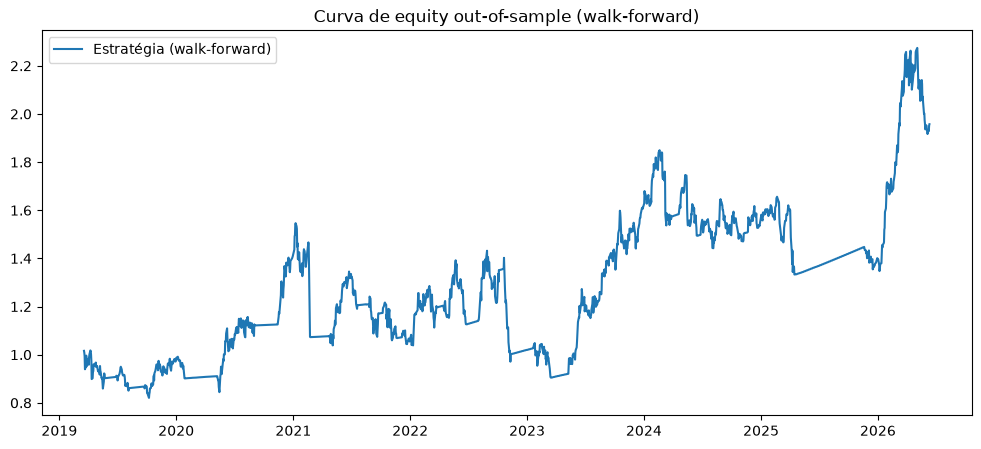

20/200    3
20/100    2
10/50     2
20/50     2
Name: count, dtype: int64


In [17]:
plt.figure(figsize=(12,5))
plt.plot(equity_walkforward, label="Estratégia (walk-forward)")
plt.legend()
plt.title("Curva de equity out-of-sample (walk-forward)")
plt.show()

print(pd.Series(escolhas).value_counts())

Usamos o benchmark somente nas datas cobertas pelo walk-forward, pois assim é possível ter uma comparação justa entre a estratégia e o benchmark. Isso acontece porque a curva de walk-forward não cobre os primeiros 800 dias que foram usados para o aquecimento das médias e para o treino inicial, então comparar com o benchmark do período todo incluiria um período onde a estratégia nunca operou.

In [18]:
retorno_benchmark_wf = df.loc[retorno_walkforward.index, "retorno_ativo"] # é a nossa referencia no periodo em que o 'retorno_walkforward' aparece, ou seja, que entraram em algum teste out-of-sample
equity_benchmark_wf = (1 + retorno_benchmark_wf).cumprod() # curva de equity no mesmo periodo

In [19]:
sharpe_estrategia = sharpe_ratio(retorno_walkforward, df["cdi"]) # aplicamos para a nossa estrategia
sharpe_benchmark = sharpe_ratio(retorno_benchmark_wf, df["cdi"]) # aplicamos para a nossa referencia

print(f"Sharpe estratégia: {sharpe_estrategia:.2f}")
print(f"Sharpe benchmark: {sharpe_benchmark:.2f}")

Sharpe estratégia: 0.15
Sharpe benchmark: 0.57


O Sharpe ratio é uma métrica que mede o retorno obtido acima da taxa livre de risco em relação ao risco tomado. Nela, o retorno médio acima do CDI (excesso de retorno) é dividido pelo desvio-padrão desse excesso, anualizado pela raiz do número de dias no ano (252). Quanto maior, mais retorno a estratégia entrega além do que se teria sem correr risco nenhum, por unidade de risco assumida.

No resultado acima, a estratégia teve Sharpe de 0.15 contra 0.57 do benchmark. Um Sharpe de 0.15 significa que a estratégia entregou muito pouco retorno acima do CDI para o risco que correu, enquanto o buy-and-hold (comprar a ação no início do período e nunca operar) foi bem mais recompensado pelo risco assumido.

In [20]:
'''calculamos o drawdown para medirmos a queda pico a pico, assim conseguimos observar qual foi a pior queda que alguem usando a estrategia que estamos fazendo sofreu'''
def max_drawdown(equity):
    pico_acumulado = equity.cummax()
    drawdown = equity / pico_acumulado - 1 #  calcula-se o equity em relacao ao maior pico ate o momento
    return drawdown.min(), drawdown

dd_estrategia, serie_dd_estrategia = max_drawdown(equity_walkforward)
dd_benchmark, serie_dd_benchmark = max_drawdown(equity_benchmark_wf)
print(f"Máximo drawdown estratégia: {dd_estrategia:.2%}")
print(f"Máximo drawdown benchmark: {dd_benchmark:.2%}")

Máximo drawdown estratégia: -41.50%
Máximo drawdown benchmark: -63.36%


O máximo drawdown mede a pior queda percentual em relação ao pico acumulado mais alto até aquele ponto, sempre respeitando a ordem cronológica dos dados para evitar o look-ahead bias.

No resultado acima, a estratégia teve drawdown de -41.50% contra -63.36% do benchmark: a estratégia reduziu a pior perda em cerca de um terço, já que ficar fora do mercado em quedas prolongadas é justamente o que o MA crossover se propõe a fazer. Ainda assim, uma queda de mais de 40% continua sendo grande, o que mostra que o atraso das médias móveis impede a estratégia de escapar de boa parte das quedas.

In [21]:
'''aqui vamos observar o retorno na metrica anual'''
def retorno_anualizado(equity, dias_no_ano = 252):
    n_dias = len(equity)
    return equity.iloc[-1] ** (dias_no_ano / n_dias) - 1 # pegamos o ultimo valor do equity (acumulado desde o inicio) para calcular o retorno anual

equity_cdi_wf = (1 + df.loc[retorno_walkforward.index, "cdi"]).cumprod() # quanto 1 real é aplicado no CDI renderia no mesmo periodo do walk-forward
ret_anual_estrategia = retorno_anualizado(equity_walkforward) 
ret_anual_benchmark = retorno_anualizado(equity_benchmark_wf) # ref
ret_anual_cdi = retorno_anualizado(equity_cdi_wf)
print(f"Retorno anualizado estratégia: {ret_anual_estrategia:.2%}")
print(f"Retorno anualizado benchmark: {ret_anual_benchmark:.2%}")
print(f"Retorno anualizado CDI: {ret_anual_cdi:.2%}")

Retorno anualizado estratégia: 9.86%
Retorno anualizado benchmark: 26.60%
Retorno anualizado CDI: 9.47%


O retorno anualizado converte o crescimento total acumulado no período em uma taxa de crescimento anual equivalente, podendo assim comparar estratégias testadas em períodos de tamanhos diferentes numa base comum.

No resultado acima, a estratégia rendeu 9.86% ao ano, contra 26.60% do buy-and-hold da PETR4 e 9.47% do CDI no mesmo período. A comparação com o CDI é a mais reveladora: a estratégia ficou apenas cerca de 0.4 ponto percentual por ano acima do que se teria sem correr risco nenhum, apesar de ficar exposta às oscilações da ação em boa parte do tempo. Ou seja, quase todo o retorno da estratégia poderia ter sido obtido deixando o dinheiro aplicado no CDI, evitando riscos. Em relação ao buy-and-hold, a estratégia abriu mão de grande parte do retorno em troca de proteção nas quedas, analisada no drawdown acima.

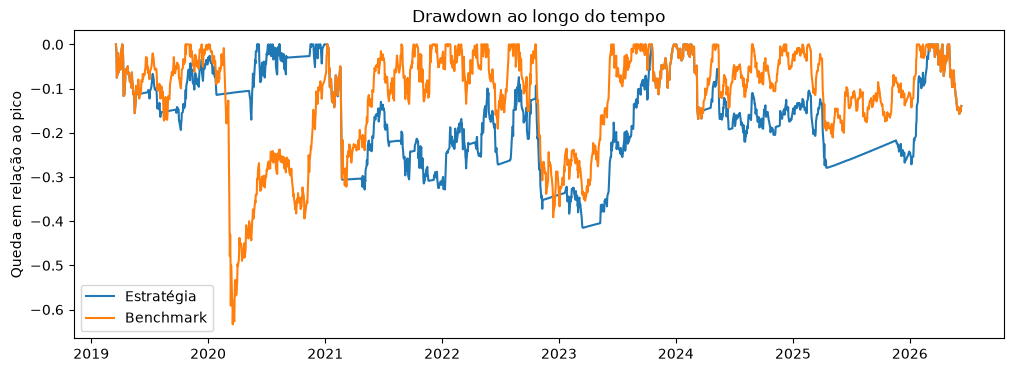

In [22]:
'''plotamos um grafico para vizualisarmos o drawdown ao longo do tempo'''
plt.figure(figsize=(12,4))
plt.plot(serie_dd_estrategia, label="Estratégia")
plt.plot(serie_dd_benchmark, label="Benchmark")
plt.legend()
plt.title("Drawdown ao longo do tempo")
plt.ylabel("Queda em relação ao pico")
plt.show()

Juntando os três números, chegamos à seguinte conclusão: a estratégia teve bem menos risco de queda que o benchmark, como mostra o drawdown de -41.50% (estratégia) contra -63.36% (benchmark). Porém, para ter essa segurança vista no drawdown, tanto o retorno anualizado (9.86% da estratégia contra 26.60% do benchmark) quanto o Sharpe (0.15 da estratégia contra 0.57 do benchmark) ficaram bem abaixo do buy-and-hold.

Esse é o trade-off esperado de qualquer estratégia trend-following como o MA crossover: apesar de reduzir a exposição durante quedas fortes, você paga esse seguro de duas formas. A estratégia entra atrasada nas tendências, perdendo o início do movimento, já que o sinal só surge depois que as médias cruzam, e também sofre com whipsaw em períodos sem direção clara, onde os cruzamentos de sinal geram operações que se cancelam. Além disso, outro ponto de extrema relevância é que a estratégia rendeu apenas cerca de 0.4 ponto percentual por ano acima do CDI (9.86% contra 9.47%), ou seja, praticamente o mesmo que se teria sem correr risco nenhum. Esse trade-off tende a compensar apenas quando o período analisado tem quedas realmente grandes para se proteger, o que não foi o caso da PETR4 no período analisado, que teve uma alta excepcionalmente forte e sustentada, deixando pouco espaço para a estratégia mostrar sua vantagem de proteção.

Por fim, uma hipótese que esses dados não permitem testar, já que usamos um único ativo em um único período, é que o MA crossover funcione melhor em ações com quedas sustentadas e prolongadas do que em quedas repentinas. Por ser uma estratégia trend-following, o atraso natural das médias móveis faz a estratégia reagir tarde demais para se proteger de um crash rápido, e sua vantagem apareceria quando a tendência de baixa se arrasta por tempo suficiente para o sinal reagir antes que a maior parte da perda aconteça.